### Gradient Boosting


XGBoost (Extreme Gradient Boosting) is a highly optimized, scalable gradient-boosted decision tree (GBDT) algorithm used for classification and regression.


### XGBoost 

Core Idea 

XGBoost builds models sequentially:

    First tree makes predictions
    
    Next tree focuses on correcting the errors of the previous trees
    
    This continues until performance improves
    
    Each new tree learns from the residuals (mistakes) of the previous trees.
    

XGBoost stands for Extreme Gradient Boosting. 

It improves upon standard gradient boosting by:

     Being faster and more accurate
    
     Providing regularization (to avoid overfitting)
    
     Supporting parallel processing
    
     Handling missing values natively
    
     Allowing early stopping and cross-validation
     

### Features

| Feature                            | Description                                                     |
| ---------------------------------- | --------------------------------------------------------------- |
| **Regularization**                 | L1 (Lasso) and L2 (Ridge) regularization to prevent overfitting |
| **Sparsity Aware**                 | Handles missing values efficiently                              |
| **Weighted Quantile Sketch**       | For approximate tree split finding on weighted data             |
| **Parallelized Tree Construction** | Makes it faster than traditional GBM                            |
| **Pruning**                        | Uses max-depth instead of depth-first for efficient pruning     |
| **Cross-validation**               | Built-in support for cross-validation with early stopping       |


In [ ]:
# ! pip install xgboost

###  1 Basic method

In [2]:

import pandas as pd

from xgboost import XGBClassifier

import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

from xgboost import plot_importance


In [3]:
dataset = pd.read_csv('diabetes.csv')
dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:

X = dataset.iloc[:, 0:8]
Y = dataset.iloc[:, 8]


In [5]:
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [6]:
Y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [7]:

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3)


In [8]:
#  Define and train XGBoost model

model = XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [9]:
#  Save the trained model to disk

with open("pima.pickle.dat", "wb") as f:
    pickle.dump(model, f)

print(" Saved model to: pima.pickle.dat")


 Saved model to: pima.pickle.dat


In [10]:
#  Load the model from disk

with open("pima.pickle.dat", "rb") as f:
    loaded_model = pickle.load(f)

print(" Loaded model from: pima.pickle.dat")


 Loaded model from: pima.pickle.dat


In [11]:
#  Make predictions and evaluate

predictions = loaded_model.predict(X_test)
predictions


array([0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0])

In [12]:
accuracy = accuracy_score(y_test, predictions)
print(f" Accuracy: {accuracy * 100:.2f}%")

 Accuracy: 74.03%


In [13]:

#  Print classification report and confusion matrix
print("\n Classification Report:\n", classification_report(y_test, predictions))
print(" Confusion Matrix:\n", confusion_matrix(y_test, predictions))



 Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.81      0.80       152
           1       0.62      0.61      0.62        79

    accuracy                           0.74       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231

 Confusion Matrix:
 [[123  29]
 [ 31  48]]


In [ ]:
### Test with a Single Unknown Patient

In [14]:
import numpy as np

# [Pregnancies, Glucose, BP, SkinThickness, Insulin, BMI, DPF, Age]
unknown_data = np.array([[2, 120, 70, 25, 80, 28.5, 0.45, 32]])

# Predict class
prediction = loaded_model.predict(unknown_data)

# Predict probability
probability = loaded_model.predict_proba(unknown_data)

print("Predicted Class:", prediction[0])
print("Prediction Probability:", probability)


Predicted Class: 0
Prediction Probability: [[0.97546643 0.0245336 ]]


In [ ]:
### Test with Multiple Unknown Records

In [15]:
unknown_batch = np.array([
    [1, 85, 66, 29, 0, 26.6, 0.35, 31],
    [5, 160, 72, 35, 120, 33.6, 0.62, 45],
    [3, 110, 68, 20, 90, 29.1, 0.40, 28]
])

preds = loaded_model.predict(unknown_batch)
probs = loaded_model.predict_proba(unknown_batch)

for i in range(len(preds)):
    print(f"Sample {i+1} → Class: {preds[i]}, Probability: {probs[i]}")


Sample 1 → Class: 0, Probability: [0.82963    0.17036997]
Sample 2 → Class: 1, Probability: [0.01847249 0.9815275 ]
Sample 3 → Class: 0, Probability: [0.9940936  0.00590638]


#### logloss


eval_metric='logloss': Tells XGBoost to use logarithmic loss as the performance metric. 

This is common for classification tasks.


### plot_importance

plot_importance(loaded_model):

Plots a bar chart of the feature importances computed by the trained loaded_model.

XGBoost ranks features based on how useful they are for building the decision trees (e.g., by gain, weight, or cover).

###  2 Plotting imp features

In [16]:
import pandas as pd
from xgboost import XGBClassifier, plot_importance
from matplotlib import pyplot as plt


In [17]:
dataset = pd.read_csv('diabetes.csv', delimiter=",")

X = dataset.iloc[:, 0:8]
Y = dataset.iloc[:, 8]


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.33, random_state=7)


In [19]:
model = XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

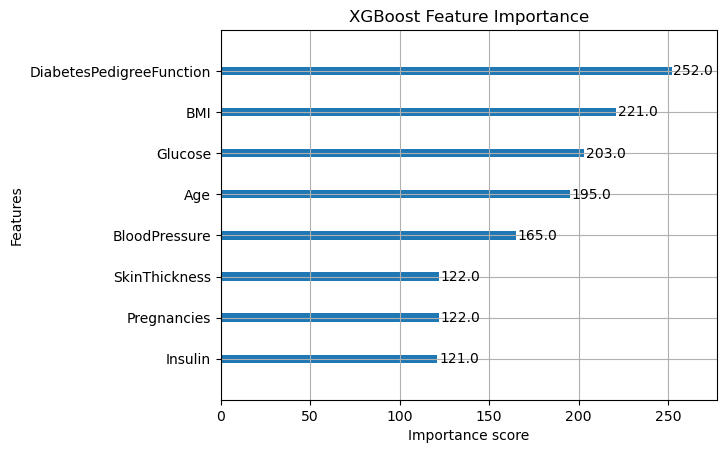

In [20]:

#  Plot feature importance
plot_importance(model)
plt.title("XGBoost Feature Importance")
plt.show()


###  3 Feature Selection using SelectFromModel

    Loads the diabetes dataset.
    
    Splits the data into training and testing sets.
    
    Trains an XGBClassifier on the training data.
    
    Evaluates the model on test data.
    
    Performs automatic feature selection based on feature importance scores.
    
    Retrains models using subsets of features based on different importance thresholds.
    
    Compares model accuracy across these subsets.

In [21]:

import pandas as pd
from numpy import sort

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectFromModel
import matplotlib.pyplot as plt


In [22]:

dataset = pd.read_csv('diabetes.csv')  

X = dataset.iloc[:, 0:8]
Y = dataset.iloc[:, 8]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.33, random_state=7)

In [24]:
#  Train initial XGBoost model
model = XGBClassifier(eval_metric='logloss')
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [25]:
#  Evaluate initial model
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print("Initial Accuracy (all features): %.2f%%" % (accuracy * 100.0))


Initial Accuracy (all features): 72.44%


In [26]:

#  Feature selection based on importance
thresholds = sort(model.feature_importances_)
thresholds

array([0.07540607, 0.07961456, 0.09396204, 0.09738518, 0.10663267,
       0.1308483 , 0.14422451, 0.2719266 ], dtype=float32)

Thresh=0.075, n=8, Accuracy: 72.44%
Thresh=0.080, n=7, Accuracy: 71.26%
Thresh=0.094, n=6, Accuracy: 71.26%
Thresh=0.097, n=5, Accuracy: 72.83%
Thresh=0.107, n=4, Accuracy: 69.29%
Thresh=0.131, n=3, Accuracy: 72.83%
Thresh=0.144, n=2, Accuracy: 70.08%
Thresh=0.272, n=1, Accuracy: 68.50%


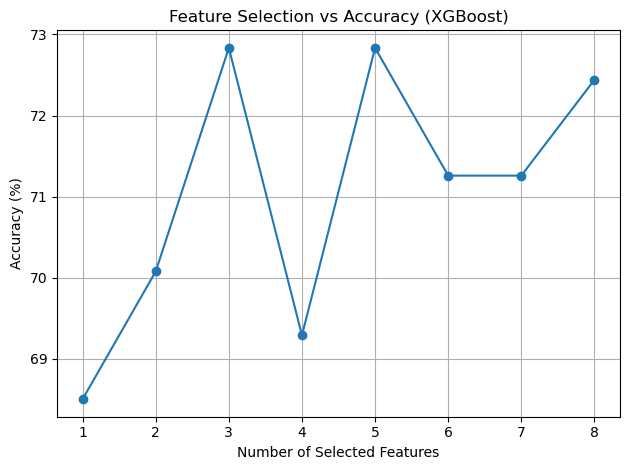

In [27]:

# Store results for plotting
accuracies = []
num_features = []

#  Iterate over thresholds and retrain models
for thresh in thresholds:
    # Select features using threshold — fit inside SelectFromModel to avoid warnings
    selection = SelectFromModel(XGBClassifier(eval_metric='logloss'), threshold=thresh)
    selection.fit(X_train, y_train)

    # Transform train/test sets
    select_X_train = selection.transform(X_train)
    select_X_test = selection.transform(X_test)

    # Train new model on selected features
    selection_model = XGBClassifier(eval_metric='logloss')
    selection_model.fit(select_X_train, y_train)

    # Predict and evaluate
    predictions = selection_model.predict(select_X_test)
    acc = accuracy_score(y_test, predictions)

    # Print results
    print("Thresh=%.3f, n=%d, Accuracy: %.2f%%" %
          (thresh, select_X_train.shape[1], acc * 100.0))

    # Store for plotting
    accuracies.append(acc)
    num_features.append(select_X_train.shape[1])

#  Plot accuracy vs number of features
plt.plot(num_features, [a * 100 for a in accuracies], marker='o')
plt.xlabel("Number of Selected Features")
plt.ylabel("Accuracy (%)")
plt.title("Feature Selection vs Accuracy (XGBoost)")
plt.grid(True)
plt.tight_layout()
plt.show()


###  4 printig validation loss

In [28]:
from numpy import sort
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectFromModel

In [29]:
dataset = pd.read_csv('diabetes.csv')

X = dataset.iloc[:, 0:8]
Y = dataset.iloc[:, 8]

In [31]:
# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split( X, Y, test_size=0.33, random_state=7)


In [32]:
# Define model with clean params
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')


In [33]:
# Evaluation set
eval_set = [(X_test, y_test)]

# Fit model
model.fit(X_train, y_train, eval_set=eval_set, verbose=True)

[0]	validation_0-logloss:0.57279
[1]	validation_0-logloss:0.53458
[2]	validation_0-logloss:0.50810
[3]	validation_0-logloss:0.50001
[4]	validation_0-logloss:0.49172
[5]	validation_0-logloss:0.49070
[6]	validation_0-logloss:0.49231
[7]	validation_0-logloss:0.48663
[8]	validation_0-logloss:0.48660
[9]	validation_0-logloss:0.48982
[10]	validation_0-logloss:0.49450
[11]	validation_0-logloss:0.49594
[12]	validation_0-logloss:0.49866
[13]	validation_0-logloss:0.50351
[14]	validation_0-logloss:0.50789
[15]	validation_0-logloss:0.51586
[16]	validation_0-logloss:0.52118
[17]	validation_0-logloss:0.52138
[18]	validation_0-logloss:0.53092
[19]	validation_0-logloss:0.53434
[20]	validation_0-logloss:0.53796
[21]	validation_0-logloss:0.54125
[22]	validation_0-logloss:0.54485
[23]	validation_0-logloss:0.54461
[24]	validation_0-logloss:0.54690
[25]	validation_0-logloss:0.55469
[26]	validation_0-logloss:0.55897
[27]	validation_0-logloss:0.56445
[28]	validation_0-logloss:0.56740
[29]	validation_0-loglos

C:\Users\nvgra\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:37:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[33]	validation_0-logloss:0.58446
[34]	validation_0-logloss:0.58759
[35]	validation_0-logloss:0.58832
[36]	validation_0-logloss:0.59044
[37]	validation_0-logloss:0.59311
[38]	validation_0-logloss:0.59869
[39]	validation_0-logloss:0.60190
[40]	validation_0-logloss:0.60366
[41]	validation_0-logloss:0.60897
[42]	validation_0-logloss:0.61300
[43]	validation_0-logloss:0.61904
[44]	validation_0-logloss:0.62217
[45]	validation_0-logloss:0.62745
[46]	validation_0-logloss:0.63016
[47]	validation_0-logloss:0.63754
[48]	validation_0-logloss:0.64335
[49]	validation_0-logloss:0.64437
[50]	validation_0-logloss:0.64856
[51]	validation_0-logloss:0.65287
[52]	validation_0-logloss:0.65816
[53]	validation_0-logloss:0.66151
[54]	validation_0-logloss:0.66817
[55]	validation_0-logloss:0.66831
[56]	validation_0-logloss:0.67144
[57]	validation_0-logloss:0.67327
[58]	validation_0-logloss:0.67762
[59]	validation_0-logloss:0.67892
[60]	validation_0-logloss:0.67854
[61]	validation_0-logloss:0.67984
[62]	validatio

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [34]:

# Predict
predictions = model.predict(X_test)


In [35]:
# Accuracy
accuracy = accuracy_score(y_test, predictions)
print("Accuracy: %.2f%%" % (accuracy * 100.0))


Accuracy: 72.44%


###  5 Train and validation loss

In [36]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from matplotlib import pyplot as plt

In [37]:
dataset = pd.read_csv('diabetes.csv')
X = dataset.iloc[:, 0:8]
Y = dataset.iloc[:, 8]


In [38]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.33, random_state=7)


In [39]:
# Define model
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0)

# Fit model
eval_set = [(X_train, y_train), (X_test, y_test)]

model.fit(X_train, y_train, eval_set=eval_set, verbose=True)

[0]	validation_0-logloss:0.51999	validation_1-logloss:0.57279
[1]	validation_0-logloss:0.44633	validation_1-logloss:0.53458
[2]	validation_0-logloss:0.39782	validation_1-logloss:0.50810
[3]	validation_0-logloss:0.36603	validation_1-logloss:0.50001
[4]	validation_0-logloss:0.32732	validation_1-logloss:0.49172
[5]	validation_0-logloss:0.30087	validation_1-logloss:0.49070
[6]	validation_0-logloss:0.28005	validation_1-logloss:0.49231
[7]	validation_0-logloss:0.25930	validation_1-logloss:0.48663
[8]	validation_0-logloss:0.24593	validation_1-logloss:0.48660
[9]	validation_0-logloss:0.23457	validation_1-logloss:0.48982
[10]	validation_0-logloss:0.22175	validation_1-logloss:0.49450
[11]	validation_0-logloss:0.20440	validation_1-logloss:0.49594
[12]	validation_0-logloss:0.19475	validation_1-logloss:0.49866
[13]	validation_0-logloss:0.18720	validation_1-logloss:0.50351
[14]	validation_0-logloss:0.17754	validation_1-logloss:0.50789
[15]	validation_0-logloss:0.16866	validation_1-logloss:0.51586
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [40]:
# Evaluate model
yhat = model.predict(X_test)
score = accuracy_score(y_test, yhat)
print("Accuracy: %.2f%%" % (accuracy * 100.0))
print('Accuracy: %.3f' % score)

Accuracy: 72.44%
Accuracy: 0.724


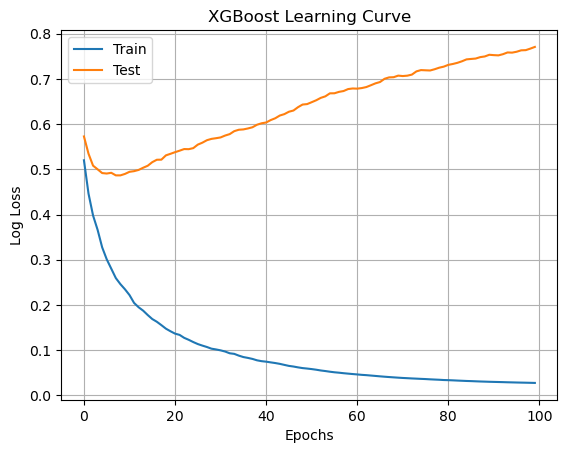

In [41]:

# Plot learning curve
results = model.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
plt.plot(x_axis, results['validation_1']['logloss'], label='Test')
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.title('XGBoost Learning Curve')
plt.legend()
plt.grid(True)
plt.show()


In [42]:
final_train_logloss = results['validation_0']['logloss'][-1]
final_test_logloss = results['validation_1']['logloss'][-1]
print(f'Final Train Log Loss: {final_train_logloss:.4f}')
print(f'Final Test Log Loss: {final_test_logloss:.4f}')

Final Train Log Loss: 0.0273
Final Test Log Loss: 0.7709


### Logarithmic Loss

Logarithmic Loss (Log Loss) is a metric used to evaluate the performance of a classification model 
 
      when the output is a probability between 0 and 1.

    Lower log loss = better model
    
    Ideal value: 0.0 (perfect prediction)
    
    It penalizes confident but wrong predictions more heavily

Why XGBoost Uses Logloss

XGBoost is probability-first, especially for classification.

    It optimizes logloss directly
    
    Works well with gradient boosting
    
    Smooth, differentiable → good for gradient descent

Parameters:

    objective='binary:logistic'
    
    eval_metric='logloss'
    

from xgboost import XGBClassifier

model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss'
)

model.fit(X_train, y_train)


For multiclass classification:

model = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=3
)

softprob → returns probability for each class

mlogloss → multi-class log loss


Logloss checks whether the probabilities predicted by your model are honest and reliable 

       — not just whether the final class is correct.
       